# Llibreries

In [2]:
import pandas as pd
import numpy as np
import json
import os
import sys
from pathlib import Path

# Visualització
import matplotlib.pyplot as plt
import seaborn as sns

# Config vis
sns.set_theme()

# Funcions
cwd = os.getcwd()
parent = os.path.abspath(os.path.join(cwd, os.pardir))
sys.path.insert(0, parent)
from src.utils import neteja_noms_columnes

# Dimensions
Carrega del dataset que conté totes les dimensions de les dades

In [3]:
dim_barris = pd.read_csv("../data/dimensions/BarcelonaCiutat_Barris.csv")
dim_barris.head()

,codi_districte,nom_districte,codi_barri,nom_barri,geometria_etrs89,geometria_wgs84
0,1,Ciutat Vella,1,el Raval,"POLYGON ((430162.1875 4581936.9845, 430102.838...","POLYGON ((2.16471378585589 41.3859301967194, 2..."
1,1,Ciutat Vella,2,el Barri Gòtic,"POLYGON ((431189.9075 4581851.4475, 431025.789...","POLYGON ((2.1770141884741 41.385248355328, 2.1..."
2,1,Ciutat Vella,3,la Barceloneta,"POLYGON ((432798.7341255 4582081.2599495, 4327...","POLYGON ((2.19622882469513 41.387454220446, 2...."
3,1,Ciutat Vella,4,"Sant Pere, Santa Caterina i la Ribera","POLYGON ((431733.736 4582441.816, 431557.5115 ...","POLYGON ((2.18345134701381 41.3906119681235, 2..."
4,2,Eixample,5,el Fort Pienc,"POLYGON ((431741.8152 4582625.6491, 432012.183...","POLYGON ((2.18352725722411 41.3922683849226, 2..."


# Carrega Datasets

In [11]:
df_2015 = pd.read_csv("../data/modelling/df_2015.csv")
df_2023 = pd.read_csv("../data/modelling/df_2023.csv")
df_deltes = pd.read_csv("../data/modelling/df_deltes.csv")

In [13]:
# Definim atributs numerics
num_vars = [col for col in df_2015 if col != "codi_barri"]

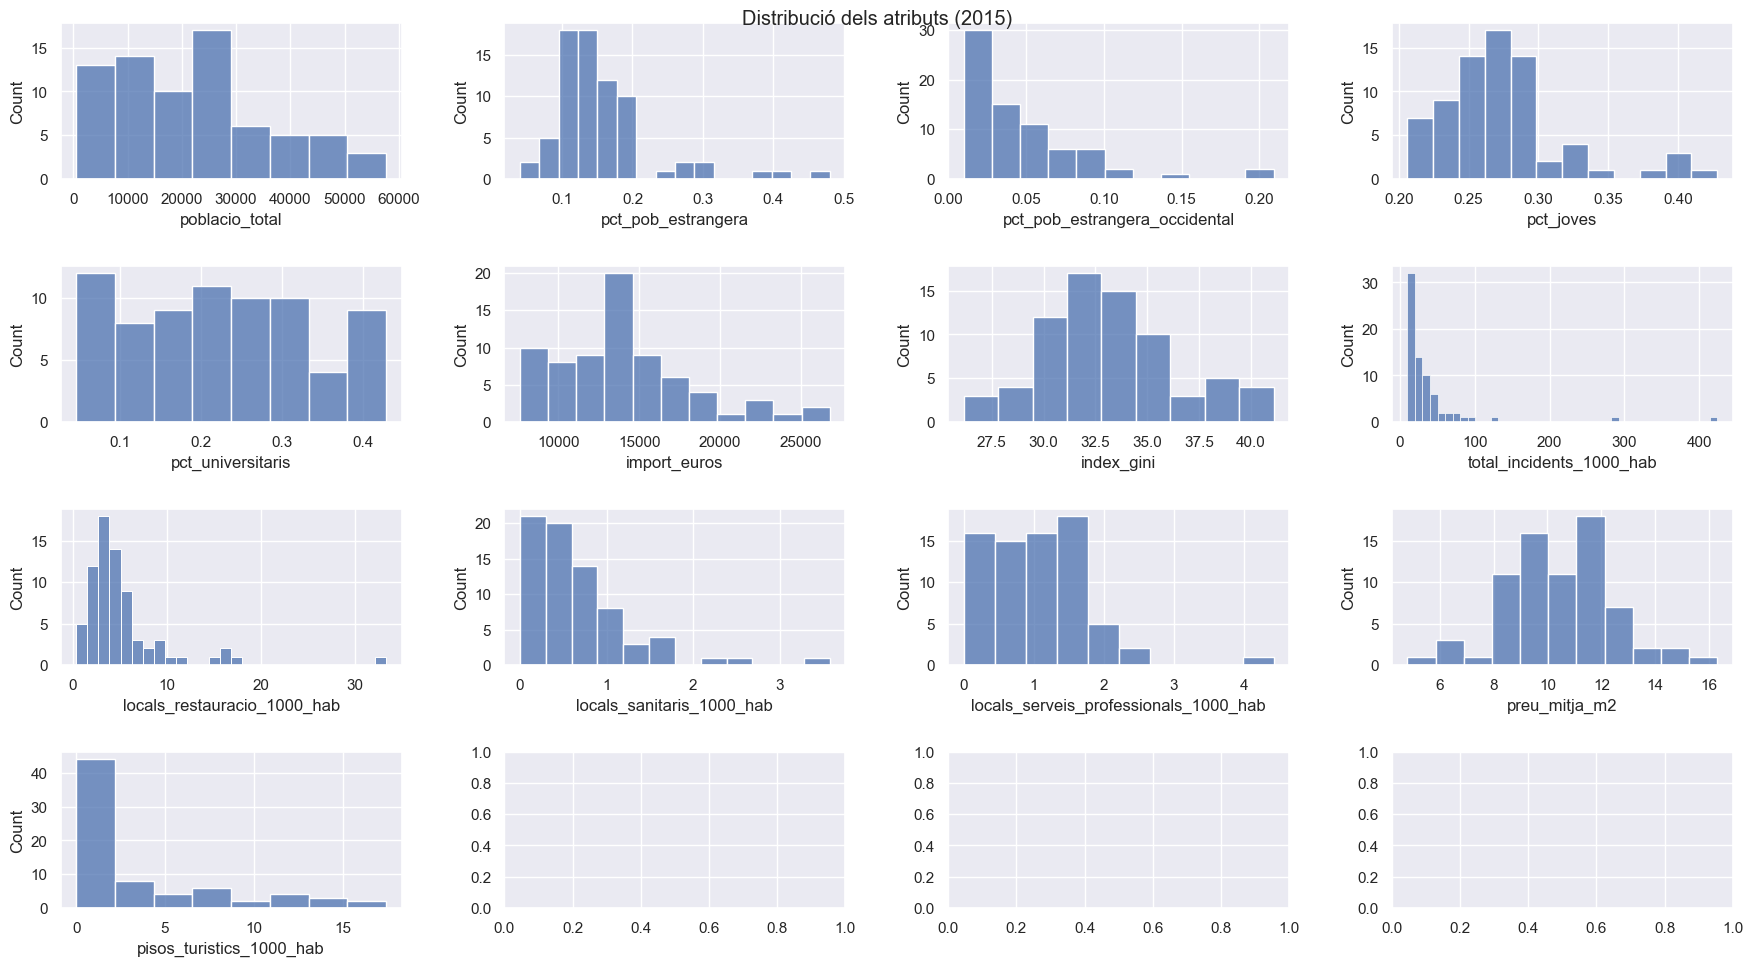

In [17]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 10))
axes = axes.reshape(-1)

for i, col in enumerate(num_vars):
    sns.histplot(df_2015[col], ax=axes[i])

fig.tight_layout(pad=2.0)
plt.suptitle('Distribució dels atributs (2015)')
plt.savefig("../results/figs/distribucions_2015.png")
plt.show()

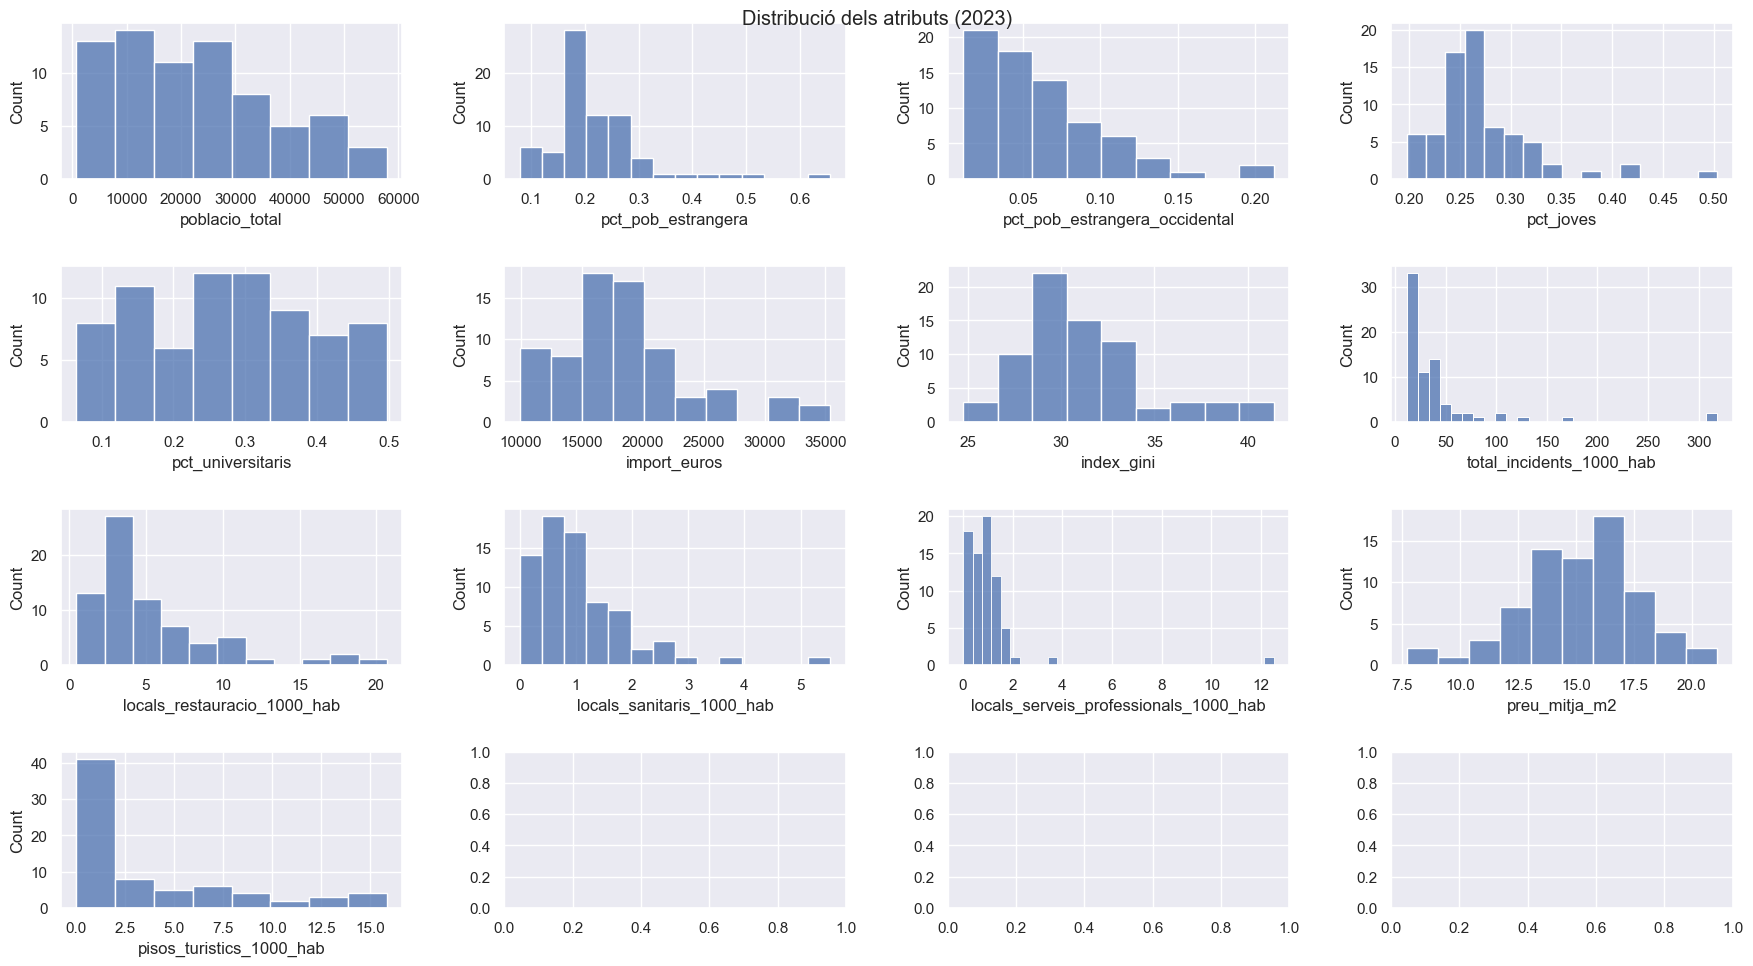

In [18]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 10))
axes = axes.reshape(-1)

for i, col in enumerate(num_vars):
    sns.histplot(df_2023[col], ax=axes[i])

fig.tight_layout(pad=2.0)
plt.suptitle('Distribució dels atributs (2023)')
plt.savefig("../results/figs/distribucions_2023.png")
plt.show()

In [19]:
df_2023.poblacio_total.describe()

count       73.000000
mean     22745.684932
std      14620.714847
min        699.000000
25%      10857.000000
50%      22041.000000
75%      30437.000000
max      57902.000000
Name: poblacio_total, dtype: float64

In [20]:
df_2015.poblacio_total.describe()

count       73.000000
mean     21982.191781
std      14493.574570
min        542.000000
25%      10371.000000
50%      20163.000000
75%      30237.000000
max      57664.000000
Name: poblacio_total, dtype: float64

In [21]:
df_2023.import_euros.describe()

count       73.000000
mean     18537.597399
std       5502.552445
min       9898.833333
25%      15134.666667
50%      17668.000000
75%      20979.111111
max      35403.000000
Name: import_euros, dtype: float64

In [22]:
df_2015.import_euros.describe()

count       73.000000
mean     14080.539259
std       4233.955597
min       7620.500000
25%      11447.444444
50%      13587.650000
75%      15441.500000
max      26779.090909
Name: import_euros, dtype: float64